# STEP 1: Import Libraries

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# STEP 2: Load Dataset

In [181]:
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset Preview:\n")
print(df.head())


Dataset Preview:

   temperature   humidity        ph  water availability season label
0    20.879744  82.002744  6.502985          202.935536  rainy  rice
1    21.770462  80.319644  7.038096          226.655537  rainy  rice
2    23.004459  82.320763  7.840207          263.964248  rainy  rice
3    26.491096  80.158363  6.980401          242.864034  rainy  rice
4    20.130175  81.604873  7.628473          262.717340  rainy  rice


In [183]:
temperature.shape

(5000,)

# STEP 3: Handle Categorical Data (Season)

In [186]:
df = pd.get_dummies(df, columns=["season"])
df

,temperature,humidity,ph,water availability,label,season_rainy,season_spring,season_summer,season_winter
0,20.879744,82.002744,6.502985,202.935536,rice,True,False,False,False
1,21.770462,80.319644,7.038096,226.655537,rice,True,False,False,False
2,23.004459,82.320763,7.840207,263.964248,rice,True,False,False,False
3,26.491096,80.158363,6.980401,242.864034,rice,True,False,False,False
4,20.130175,81.604873,7.628473,262.717340,rice,True,False,False,False
...,...,...,...,...,...,...,...,...,...
1395,23.874845,86.792613,6.718725,177.514731,jute,True,False,False,False
1396,23.928879,88.071123,6.880205,154.660874,jute,True,False,False,False
1397,24.814412,81.686889,6.861069,190.788639,jute,True,False,False,False
1398,24.447439,82.286484,6.769346,190.968489,jute,True,False,False,False


In [188]:
yield_data

array([109.34876156,  75.89708906,  78.96880546, ...,  88.23330411,
        85.7612539 ,  83.96371119])

# STEP 4: Define Features & Target

In [191]:
X = df.drop("label", axis=1)
y = df["label"]

In [193]:
X.head()

,temperature,humidity,ph,water availability,season_rainy,season_spring,season_summer,season_winter
0,20.879744,82.002744,6.502985,202.935536,True,False,False,False
1,21.770462,80.319644,7.038096,226.655537,True,False,False,False
2,23.004459,82.320763,7.840207,263.964248,True,False,False,False
3,26.491096,80.158363,6.980401,242.864034,True,False,False,False
4,20.130175,81.604873,7.628473,262.717340,True,False,False,False


In [195]:
y.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

# STEP 5: Train-Test Split

In [198]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [200]:
# X_train,X_test,y_train,y_test

# STEP 6: Train Model

In [203]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# STEP 7: Predictions

In [205]:
y_pred = model.predict(X_test)

In [206]:
y_pred

array(['mungbean', 'mungbean', 'maize', 'pigeonpeas', 'chickpea',
       'blackgram', 'chickpea', 'lentil', 'maize', 'pigeonpeas', 'maize',
       'maize', 'blackgram', 'blackgram', 'kidneybeans', 'kidneybeans',
       'mothbeans', 'mungbean', 'chickpea', 'jute', 'rice', 'chickpea',
       'chickpea', 'mungbean', 'rice', 'rice', 'rice', 'watermelon',
       'watermelon', 'pigeonpeas', 'blackgram', 'mothbeans', 'lentil',
       'blackgram', 'maize', 'pigeonpeas', 'chickpea', 'blackgram',
       'jute', 'watermelon', 'rice', 'watermelon', 'mothbeans', 'lentil',
       'kidneybeans', 'maize', 'watermelon', 'lentil', 'rice',
       'blackgram', 'blackgram', 'rice', 'mothbeans', 'muskmelon',
       'muskmelon', 'mothbeans', 'kidneybeans', 'lentil', 'chickpea',
       'pigeonpeas', 'chickpea', 'maize', 'lentil', 'maize', 'pigeonpeas',
       'maize', 'muskmelon', 'chickpea', 'kidneybeans', 'maize',
       'muskmelon', 'mothbeans', 'blackgram', 'lentil', 'chickpea',
       'chickpea', 'maize'

# STEP 8: Evaluation

In [211]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.9892857142857143

Classification Report:

              precision    recall  f1-score   support

   blackgram       1.00      1.00      1.00        22
    chickpea       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        14
        jute       0.90      1.00      0.95        18
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        23
       maize       0.97      1.00      0.99        39
   mothbeans       1.00      1.00      1.00        22
    mungbean       1.00      1.00      1.00        21
   muskmelon       1.00      1.00      1.00        20
  pigeonpeas       1.00      0.95      0.97        20
        rice       1.00      0.89      0.94        19
  watermelon       1.00      1.00      1.00        20

    accuracy                           0.99       280
   macro avg       0.99      0.99      0.99       280
weighted avg       0.99      0.99      0.99       280



# STEP 9: Feature Importance

In [214]:
importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print("\nFeature Importance:\n")
print(feat_imp)



Feature Importance:

humidity              0.308050
water availability    0.227403
temperature           0.135555
ph                    0.094781
season_summer         0.062671
season_rainy          0.061411
season_winter         0.060391
season_spring         0.049737
dtype: float64


# STEP 10: Visualization

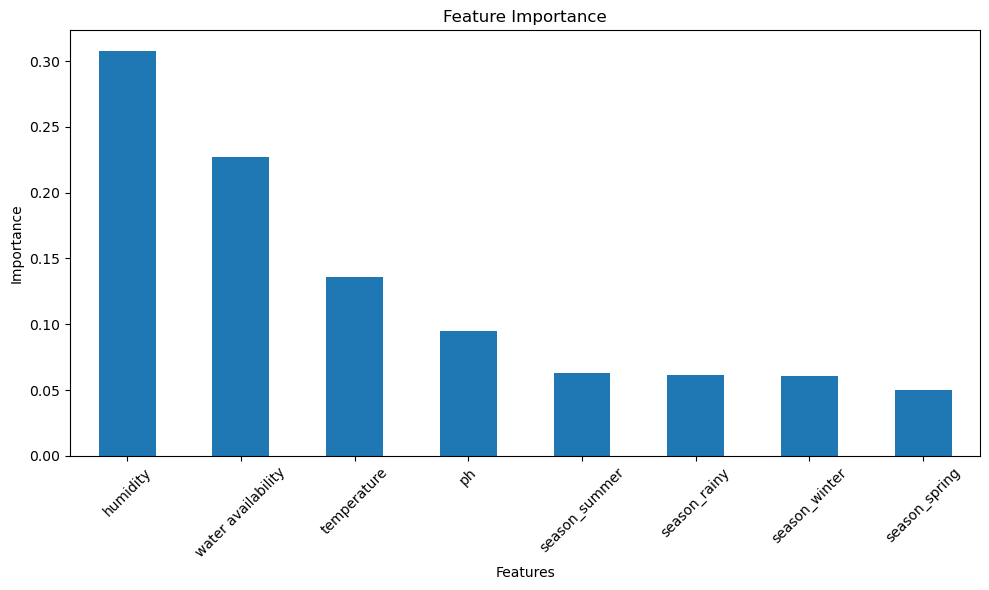

In [217]:
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()